In [1]:
!pip install -q nibabel SimpleITK scikit-image scipy torch torchvision tqdm pandas matplotlib

In [2]:
import os, json, warnings, itertools
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import nibabel as nib
import SimpleITK as sitk

from scipy.ndimage import label, binary_fill_holes, binary_erosion, binary_dilation
from scipy.interpolate import splprep, splev
from scipy.spatial import cKDTree

from skimage.morphology import skeletonize, ball
from skimage.exposure import equalize_adapthist

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = Path("/content/drive/MyDrive/Colab Notebooks/MIAProject2")

DATA_ROOT = DRIVE_BASE / "data" / "Train"
TEST_ROOT = DRIVE_BASE / "data" / "Test"
OUT_DIR   = DRIVE_BASE / "output"
CACHE_DIR = Path("/content/preproc_cache")
OUT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CFG = dict(
    patch_size   = (64, 64, 64),   # was 96 — smaller patches = faster + less VRAM
    batch_size   = 4,              # was 2 — bigger batch with smaller patches
    lr           = 3e-4,           # was 1e-4 — higher LR for fewer epochs
    epochs_a     = 30,             # was 100
    epochs_b     = 40,             # was 150
    val_frac     = 0.15,           # was 0.20 — more training data
    n_workers    = 2,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [4]:
def load_nifti(path: Path) -> Tuple[np.ndarray, np.ndarray, nib.Nifti1Image]:
    """Return (data_float32, voxel_spacing_mm, nibabel_img)."""
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    spacing = np.array(img.header.get_zooms()[:3], dtype=np.float32)
    return data, spacing, img


def save_nifti(mask: np.ndarray, ref_img: nib.Nifti1Image, path: Path):
    """Save uint8 binary mask using the reference image's affine and header."""
    out = nib.Nifti1Image(mask.astype(np.uint8), ref_img.affine, ref_img.header)
    nib.save(out, str(path))


def get_subject_paths(root: Path, labeled: bool = True) -> List[dict]:
    """Return sorted list of per-subject path dicts."""
    subjects = sorted(root.glob("subj*"))
    records = []
    for s in subjects:
        sid = s.name
        rec = {"id": sid, "image": s / f"{sid}_image.nii.gz"}
        if labeled:
            rec["artifact"] = s / f"{sid}_artifact.nii.gz"
            rec["catheter"] = s / f"{sid}_catheter.nii.gz"
            json_path = s / f"{sid}.json"
            if json_path.exists():
                rec["json"] = json_path
        records.append(rec)
    return records


# Sanity check
if DATA_ROOT.exists():
    records = get_subject_paths(DATA_ROOT)
    r0 = records[0]
    img, sp, _ = load_nifti(r0["image"])
    print(f"Subjects: {len(records)} | Volume shape: {img.shape} | Spacing: {sp} mm")
else:
    print(f"DATA_ROOT '{DATA_ROOT}' not found — check your Drive path.")

Subjects: 200 | Volume shape: (192, 224, 192) | Spacing: [1. 1. 1.] mm


In [5]:
def clahe_volume(vol: np.ndarray) -> np.ndarray:
    """Apply 2D CLAHE slice-by-slice along the axial axis."""
    out = np.zeros_like(vol)
    v_min, v_max = vol.min(), vol.max()
    vol_norm = (vol - v_min) / (v_max - v_min + 1e-8)
    for z in range(vol.shape[2]):
        out[..., z] = equalize_adapthist(vol_norm[..., z], clip_limit=0.03)
    return out


def intensity_normalise(vol: np.ndarray) -> np.ndarray:
    """Clip to [0.5%, 99.5%] percentile then z-score."""
    lo, hi = np.percentile(vol, 0.5), np.percentile(vol, 99.5)
    vol = np.clip(vol, lo, hi)
    return (vol - vol.mean()) / (vol.std() + 1e-8)


def preprocess_volume(path: Path, use_cache: bool = True) -> np.ndarray:
    """
    Lightweight preprocessing: CLAHE → z-score (skip N4 for speed).
    N4 takes ~2-3 min per subject; skipping it saves ~7+ hours on 200 subjects.
    CLAHE + z-score alone is usually sufficient for U-Net training.
    """
    cache_key = Path(path).name.replace('.nii.gz', '').replace('.nii', '')
    cache_path = CACHE_DIR / (cache_key + '_pre.npy')
    if use_cache and cache_path.exists():
        return np.load(str(cache_path))

    vol, _, _ = load_nifti(path)
    vol = clahe_volume(vol)
    vol = intensity_normalise(vol).astype(np.float32)

    if use_cache:
        np.save(str(cache_path), vol)
    return vol

In [6]:
class ConvBnRelu(nn.Module):
    """Two 3x3x3 convolutions with InstanceNorm and LeakyReLU."""
    def __init__(self, cin, cout, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(cin, cout, k, padding=p, bias=False),
            nn.InstanceNorm3d(cout),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(cout, cout, k, padding=p, bias=False),
            nn.InstanceNorm3d(cout),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    """MaxPool3d(2) then double conv — halves spatial dims, doubles channels."""
    def __init__(self, cin, cout):
        super().__init__()
        self.pool = nn.MaxPool3d(2)
        self.conv = ConvBnRelu(cin, cout)
    def forward(self, x):
        return self.conv(self.pool(x))


class UpBlock(nn.Module):
    """Transposed conv upsample, concatenate skip connection, double conv."""
    def __init__(self, cin, cout):
        super().__init__()
        self.up = nn.ConvTranspose3d(cin, cout, kernel_size=2, stride=2)
        self.conv = ConvBnRelu(cin, cout)  # cin not cout: input is skip+upsampled concatenated
    def forward(self, x, skip):
        x = self.up(x)
        # Pad by 1 voxel if skip and x have different sizes (odd input dimensions)
        diff = [s - x.shape[i+2] for i, s in enumerate(skip.shape[2:])]
        x = F.pad(x, [0, diff[2], 0, diff[1], 0, diff[0]])
        return self.conv(torch.cat([skip, x], dim=1))


class UNet3D(nn.Module):
    """
    4-level 3D U-Net.
    Task A: in_channels=1 (MRI only)
    Task B: in_channels=2 (MRI + artifact mask)
    """
    def __init__(self, in_channels: int = 1, base: int = 16, out_classes: int = 1):
        super().__init__()
        b = base
        self.enc0 = ConvBnRelu(in_channels, b)
        self.enc1 = DownBlock(b, b*2)
        self.enc2 = DownBlock(b*2, b*4)
        self.enc3 = DownBlock(b*4, b*8)
        self.bot  = DownBlock(b*8, b*16)
        self.dec3 = UpBlock(b*16, b*8)
        self.dec2 = UpBlock(b*8, b*4)
        self.dec1 = UpBlock(b*4, b*2)
        self.dec0 = UpBlock(b*2, b)
        self.head = nn.Conv3d(b, out_classes, 1)

    def forward(self, x):
        e0 = self.enc0(x)
        e1 = self.enc1(e0)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b  = self.bot(e3)
        d3 = self.dec3(b, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        d0 = self.dec0(d1, e0)
        return self.head(d0)  # raw logits, shape (B, 1, X, Y, Z)


_net_a = UNet3D(in_channels=1, base=16)
_net_b = UNet3D(in_channels=2, base=16)
print(f"Task-A U-Net params: {sum(p.numel() for p in _net_a.parameters())/1e6:.2f}M")
print(f"Task-B U-Net params: {sum(p.numel() for p in _net_b.parameters())/1e6:.2f}M")
del _net_a, _net_b

Task-A U-Net params: 5.64M
Task-B U-Net params: 5.64M


In [ ]:
class PatchDataset(Dataset):
    """
    Randomly samples 96^3 patches from preprocessed volumes.
    Task A: input = MRI (1ch), label = artifact mask
    Task B: input = MRI + artifact mask (2ch), label = catheter mask
    """
    def __init__(self, records: List[dict], task: str = 'A',
                 patch_size: Tuple = (96, 96, 96),
                 patches_per_vol: int = 16,
                 fg_oversample: float = 0.5):
        assert task in ('A', 'B')
        self.records = records
        self.task = task
        self.patch_size = np.array(patch_size)
        self.patches_per_vol = patches_per_vol
        self.fg_oversample = fg_oversample
        self._cache = {}

    def _load(self, rec: dict):
        sid = rec["id"]
        if sid not in self._cache:
            vol = preprocess_volume(rec["image"])
            art, _, _ = load_nifti(rec["artifact"])
            cat, _, _ = load_nifti(rec["catheter"])
            self._cache[sid] = (vol.astype(np.float32),
                                art.astype(np.float32),
                                cat.astype(np.float32))
        return self._cache[sid]

    def _sample_origin(self, vol_shape, label_vol):
        """Pick random patch origin, biased toward foreground voxels."""
        ps = self.patch_size
        sh = np.array(vol_shape)
        fg = np.argwhere(label_vol > 0)

        if len(fg) > 0 and np.random.rand() < self.fg_oversample:
            centre = fg[np.random.randint(len(fg))]
        else:
            centre = np.array([np.random.randint(p // 2, max(p // 2 + 1, s - p // 2))
                               for s, p in zip(sh, ps)])

        lo = np.clip(centre - ps // 2, 0, sh - ps)
        return tuple(int(l) for l in lo)

    def _extract(self, vol, lo):
        ps = self.patch_size
        return vol[lo[0]:lo[0]+ps[0], lo[1]:lo[1]+ps[1], lo[2]:lo[2]+ps[2]]

    def __len__(self):
        return len(self.records) * self.patches_per_vol

    def __getitem__(self, idx):
        rec = self.records[idx // self.patches_per_vol]
        vol, art, cat = self._load(rec)

        if self.task == 'A':
            lo = self._sample_origin(vol.shape, art)
            img_p = self._extract(vol, lo)
            lbl_p = self._extract(art, lo)

            # Augmentation: random flips + intensity jitter
            for ax in range(3):
                if np.random.rand() < 0.5:
                    img_p = np.flip(img_p, axis=ax).copy()
                    lbl_p = np.flip(lbl_p, axis=ax).copy()
            img_p = img_p * np.random.uniform(0.9, 1.1) + np.random.uniform(-0.1, 0.1)

            img_t = torch.from_numpy(img_p).unsqueeze(0).float()
            lbl_t = torch.from_numpy(lbl_p).unsqueeze(0).float()

        else:  # Task B
            lo = self._sample_origin(vol.shape, cat)
            img_p = self._extract(vol, lo)
            art_p = self._extract(art, lo)
            lbl_p = self._extract(cat, lo)

            # Augment all three with identical flips
            for ax in range(3):
                if np.random.rand() < 0.5:
                    img_p = np.flip(img_p, axis=ax).copy()
                    art_p = np.flip(art_p, axis=ax).copy()
                    lbl_p = np.flip(lbl_p, axis=ax).copy()
            img_p = img_p * np.random.uniform(0.9, 1.1) + np.random.uniform(-0.1, 0.1)

            ch0 = torch.from_numpy(img_p).unsqueeze(0)
            ch1 = torch.from_numpy(art_p).unsqueeze(0)
            img_t = torch.cat([ch0, ch1], dim=0).float()
            lbl_t = torch.from_numpy(lbl_p).unsqueeze(0).float()

        return img_t, lbl_t

In [ ]:
def dice_loss(pred_logits, target, smooth=1e-5):
    pred = torch.sigmoid(pred_logits)
    inter = (pred * target).sum(dim=(2, 3, 4))
    union = pred.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4))
    dice = (2 * inter + smooth) / (union + smooth)
    return 1 - dice.mean()


def combo_loss(pred_logits, target, alpha=0.5):
    """Task A loss: 0.5 * Dice + 0.5 * BCE."""
    dloss = dice_loss(pred_logits, target)
    bce = F.binary_cross_entropy_with_logits(pred_logits, target, reduction="mean")
    return alpha * dloss + (1 - alpha) * bce


def catheter_loss(pred_logits, target):
    """Task B loss: Dice + BCE (same as Task A — simpler and more stable)."""
    return combo_loss(pred_logits, target)

In [ ]:
def plot_history(history: dict, title: str = "Training"):
    """Plot train/val loss curves."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["train"], label="Train")
    ax.plot(history["val"], label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def train_unet(model: nn.Module,
               train_loader: DataLoader,
               val_loader: DataLoader,
               n_epochs: int,
               loss_fn,
               lr: float = 1e-4,
               ckpt_path: str = "best_model.pt"):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    best_val_loss = float("inf")
    history = {"train": [], "val": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        tloss = 0.0
        for img, lbl in train_loader:
            img, lbl = img.to(DEVICE), lbl.to(DEVICE)
            opt.zero_grad()
            pred = model(img)
            loss = loss_fn(pred, lbl)
            if loss.ndim > 0:
                loss = loss.mean()
            loss.backward()
            opt.step()
            tloss += loss.item()
        sched.step()
        tloss /= len(train_loader)

        model.eval()
        vloss = 0.0
        with torch.no_grad():
            for img, lbl in val_loader:
                img, lbl = img.to(DEVICE), lbl.to(DEVICE)
                pred = model(img)
                loss = loss_fn(pred, lbl)
                if loss.ndim > 0:
                    loss = loss.mean()
                vloss += loss.item()
        vloss /= len(val_loader)

        history["train"].append(tloss)
        history["val"].append(vloss)

        if vloss < best_val_loss:
            best_val_loss = vloss
            torch.save(model.state_dict(), ckpt_path)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{n_epochs} | train {tloss:.5f} | val {vloss:.5f}")

    print(f"  Best val loss: {best_val_loss:.5f} — saved to {ckpt_path}")
    return history

In [7]:
# if DATA_ROOT.exists():
#     records = get_subject_paths(DATA_ROOT)
#     n_val = int(len(records) * CFG["val_frac"])
#     rng = np.random.default_rng(SEED)
#     idx = rng.permutation(len(records))
#     train_r = [records[i] for i in idx[n_val:]]
#     val_r   = [records[i] for i in idx[:n_val]]
#     print(f"Train: {len(train_r)} subjects | Val: {len(val_r)} subjects")

#     ds_a_tr = PatchDataset(train_r, task='A', patch_size=CFG["patch_size"],
#                            patches_per_vol=8, fg_oversample=0.5)
#     ds_a_val = PatchDataset(val_r, task='A', patch_size=CFG["patch_size"],
#                             patches_per_vol=4, fg_oversample=0.5)
#     dl_a_tr = DataLoader(ds_a_tr, batch_size=CFG["batch_size"],
#                          shuffle=True, num_workers=CFG["n_workers"], pin_memory=True)
#     dl_a_val = DataLoader(ds_a_val, batch_size=CFG["batch_size"],
#                           shuffle=False, num_workers=CFG["n_workers"], pin_memory=True)

#     model_a = UNet3D(in_channels=1, base=16)
#     hist_a = train_unet(model_a, dl_a_tr, dl_a_val,
#                         n_epochs=CFG["epochs_a"],
#                         loss_fn=combo_loss,
#                         lr=CFG["lr"],
#                         ckpt_path=str(OUT_DIR / "model_a_best.pt"))
#     plot_history(hist_a, title="Task A — Artifact U-Net")
# else:
#     print("DATA_ROOT not found — check path.")

if DATA_ROOT.exists():
    records = get_subject_paths(DATA_ROOT)
    n_val = int(len(records) * CFG["val_frac"])
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(len(records))
    train_r = [records[i] for i in idx[n_val:]]
    val_r   = [records[i] for i in idx[:n_val]]
    print(f"Train: {len(train_r)} subjects | Val: {len(val_r)} subjects")

    # Load already-trained Task A model from Drive (skip retraining)
    model_a = UNet3D(in_channels=1, base=16).to(DEVICE)
    model_a.load_state_dict(torch.load(str(OUT_DIR / "model_a_best.pt"), map_location=DEVICE))
    print("Loaded model_a from checkpoint.")

Train: 170 subjects | Val: 30 subjects
Loaded model_a from checkpoint.


  Epoch   1/40 | train 0.72382 | val 0.65234
  Epoch  10/40 | train 0.21845 | val 0.20719
  Epoch  20/40 | train 0.14354 | val 0.14107
  Epoch  30/40 | train 0.11731 | val 0.12818
  Epoch  40/40 | train 0.10439 | val 0.13773
  Best val loss: 0.10477 — saved to /content/drive/MyDrive/Colab Notebooks/MIAProject2/output/model_b_best.pt


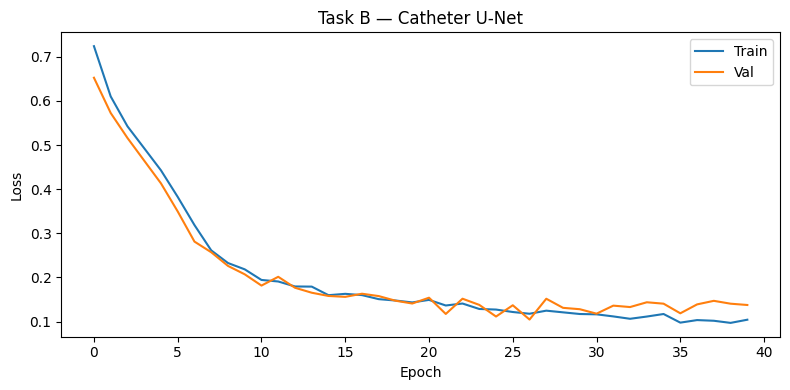

In [ ]:
if DATA_ROOT.exists():
    ds_b_tr = PatchDataset(train_r, task='B', patch_size=CFG["patch_size"],
                           patches_per_vol=12, fg_oversample=0.7)
    ds_b_val = PatchDataset(val_r, task='B', patch_size=CFG["patch_size"],
                            patches_per_vol=4, fg_oversample=0.7)
    dl_b_tr = DataLoader(ds_b_tr, batch_size=CFG["batch_size"],
                         shuffle=True, num_workers=CFG["n_workers"], pin_memory=True)
    dl_b_val = DataLoader(ds_b_val, batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["n_workers"], pin_memory=True)

    model_b = UNet3D(in_channels=2, base=16)
    hist_b = train_unet(model_b, dl_b_tr, dl_b_val,
                        n_epochs=CFG["epochs_b"],
                        loss_fn=catheter_loss,
                        lr=CFG["lr"],
                        ckpt_path=str(OUT_DIR / "model_b_best.pt"))
    plot_history(hist_b, title="Task B — Catheter U-Net")

In [10]:
model_b = UNet3D(in_channels=2, base=16).to(DEVICE)
model_b.load_state_dict(torch.load(str(OUT_DIR / "model_b_best.pt"),
                                   map_location=DEVICE))
print("Loaded model_b from checkpoint.")

Loaded model_b from checkpoint.


In [15]:
def sliding_window_inference(model: nn.Module,
                             vol: np.ndarray,
                             patch_size: Tuple = (64, 64, 64),
                             stride: int = 32,
                             extra_ch: Optional[np.ndarray] = None,
                             threshold: float = 0.5,
                             return_prob: bool = False) -> np.ndarray:
    """
    Gaussian-weighted sliding window over full volume.
    - Default stride changed from 48 → 32 (more overlap → smoother for thin tubes).
    - return_prob=True returns raw probability map (used by TTA wrapper).
    """
    model.eval()
    ps = np.array(patch_size)
    sh = np.array(vol.shape)
    prob = np.zeros(sh, dtype=np.float32)
    cnt  = np.zeros(sh, dtype=np.float32)

    g1d  = np.exp(-4 * (np.linspace(-1, 1, ps[0]) ** 2))
    kern = g1d[:, None, None] * g1d[None, :, None] * g1d[None, None, :]

    starts = [range(0, max(s - p, 1), stride) for s, p in zip(sh, ps)]
    for xs, ys, zs in itertools.product(*starts):
        xe = min(xs + ps[0], sh[0]); ye = min(ys + ps[1], sh[1]); ze = min(zs + ps[2], sh[2])
        xs2, ys2, zs2 = xe - ps[0], ye - ps[1], ze - ps[2]

        patch  = vol[xs2:xe, ys2:ye, zs2:ze]
        tensor = torch.from_numpy(patch[None, None]).float().to(DEVICE)
        if extra_ch is not None:
            ext = extra_ch[xs2:xe, ys2:ye, zs2:ze]
            tensor = torch.cat([tensor,
                                torch.from_numpy(ext[None, None]).float().to(DEVICE)], dim=1)
        with torch.no_grad():
            logit = model(tensor)[0, 0].cpu().numpy()
        pred_prob = 1 / (1 + np.exp(-logit))

        prob[xs2:xe, ys2:ye, zs2:ze] += pred_prob * kern
        cnt [xs2:xe, ys2:ye, zs2:ze] += kern

    prob /= (cnt + 1e-8)
    if return_prob:
        return prob
    return (prob >= threshold).astype(np.uint8)


def sliding_window_inference_tta(model: nn.Module,
                                 vol: np.ndarray,
                                 patch_size: Tuple = (64, 64, 64),
                                 stride: int = 32,
                                 extra_ch: Optional[np.ndarray] = None,
                                 threshold: float = 0.5) -> np.ndarray:
    """
    8-flip test-time augmentation: run inference on every combination of
    axis flips, un-flip the probabilities, average, then threshold.
    Un-flipping is CRITICAL — averaging flipped probability maps directly
    would cancel them out. When extra_ch is given (Task B), both the MRI
    volume and the artifact-mask channel are flipped consistently.
    """
    prob_sum = np.zeros(vol.shape, dtype=np.float32)
    for fz, fy, fx in itertools.product([False, True], repeat=3):
        axes = tuple(a for a, f in zip((0, 1, 2), (fz, fy, fx)) if f)

        vol_f   = np.flip(vol, axis=axes).copy() if axes else vol
        extra_f = None
        if extra_ch is not None:
            extra_f = np.flip(extra_ch, axis=axes).copy() if axes else extra_ch

        prob_f = sliding_window_inference(model, vol_f,
                                          patch_size=patch_size, stride=stride,
                                          extra_ch=extra_f, return_prob=True)

        # Un-flip probability map back to original orientation BEFORE averaging
        prob_sum += np.flip(prob_f, axis=axes).copy() if axes else prob_f

    prob_mean = prob_sum / 8.0
    return (prob_mean >= threshold).astype(np.uint8)


def post_process_artifact(mask: np.ndarray) -> np.ndarray:
    """Keep only the largest connected component (there is exactly one valve)."""
    labeled_arr, n = label(mask)
    if n == 0:
        return mask
    sizes = [np.sum(labeled_arr == i) for i in range(1, n + 1)]
    biggest = np.argmax(sizes) + 1
    return (labeled_arr == biggest).astype(np.uint8)


def post_process_catheter(cath_mask: np.ndarray,
                          art_mask: np.ndarray,
                          close_radius: int = 1,
                          min_cc_fraction: float = 0.1) -> np.ndarray:
    """
    Post-processing for predicted catheter:
      1) Zero any voxels overlapping the artifact mask.
      2) Morphological closing (ball of radius close_radius) to heal 1-2 voxel gaps.
      3) Connected-component filter: keep the largest, plus any CC whose size
         is >= min_cc_fraction of the largest (catches a rare second branch
         without admitting speckle).
      4) Re-zero any overlap with the artifact that closing may have reintroduced.
    """
    cath = np.where(art_mask > 0, 0, cath_mask).astype(np.uint8)
    if cath.sum() == 0:
        return cath

    if close_radius > 0:
        struct = ball(close_radius)
        cath = binary_dilation(cath.astype(bool), structure=struct)
        cath = binary_erosion(cath,               structure=struct).astype(np.uint8)
        cath = np.where(art_mask > 0, 0, cath).astype(np.uint8)

    labeled_arr, n = label(cath)
    if n == 0:
        return cath
    sizes = np.array([np.sum(labeled_arr == i) for i in range(1, n + 1)])
    biggest = sizes.max()
    keep_ids = (np.where(sizes >= max(1, min_cc_fraction * biggest))[0] + 1).tolist()
    return np.isin(labeled_arr, keep_ids).astype(np.uint8)

In [13]:
def extract_ordered_skeleton(mask: np.ndarray, spacing: np.ndarray) -> np.ndarray:
    """
    Skeletonize the catheter mask, find the two farthest-apart endpoints,
    then walk greedily from one to the other.
    Returns ordered points in mm, shape (N, 3).
    """
    struct = ball(1)
    dilated = binary_dilation(mask.astype(bool), struct)
    skel = skeletonize(dilated)
    coords_vox = np.argwhere(skel)

    if len(coords_vox) < 2:
        coords_vox = np.argwhere(mask > 0)
        if len(coords_vox) < 2:
            return coords_vox * spacing[None, :]

    coords_mm = coords_vox * spacing[None, :]

    # 2-pass endpoint finding: pick any point → find farthest → find farthest from that
    seed = coords_mm[0]
    dists = np.linalg.norm(coords_mm - seed, axis=1)
    a_idx = np.argmax(dists)
    dists_a = np.linalg.norm(coords_mm - coords_mm[a_idx], axis=1)
    b_idx = np.argmax(dists_a)

    # Greedy nearest-neighbor walk from endpoint A
    visited = [a_idx]
    remaining = set(range(len(coords_mm))) - {a_idx}
    while remaining:
        last = visited[-1]
        cands = list(remaining)
        dists = np.linalg.norm(coords_mm[cands] - coords_mm[last], axis=1)
        nxt = cands[np.argmin(dists)]
        visited.append(nxt)
        remaining.remove(nxt)

    return coords_mm[visited]


def fit_best_spline(ordered_pts_mm: np.ndarray, mask: np.ndarray,
                    spacing: np.ndarray, max_anchor: int = 10):
    """
    Try splines with anchor spacing 1..max_anchor.
    Pick the one with lowest MSE to the original mask voxels.
    Returns (arc_length_mm, tck).
    """
    mask_coords = np.argwhere(mask > 0).astype(float) * spacing[None, :]
    best_mse = np.inf
    best_length = 0.0
    best_tck = None

    for anchor_step in range(1, max_anchor + 1):
        anchors = ordered_pts_mm[::anchor_step]
        if not np.allclose(anchors[-1], ordered_pts_mm[-1]):
            anchors = np.vstack([anchors, ordered_pts_mm[-1]])
        if len(anchors) < 4:
            continue
        try:
            tck, u = splprep(anchors.T, s=0, k=3)
        except Exception:
            continue

        t_fine = np.linspace(0, 1, 1000)
        dx, dy, dz = splev(t_fine, tck, der=1)
        speed = np.sqrt(dx**2 + dy**2 + dz**2)
        length = float(np.trapz(speed, t_fine))

        x, y, z = splev(t_fine, tck)
        spline_pts = np.column_stack([x, y, z])
        tree = cKDTree(spline_pts)
        dists, _ = tree.query(mask_coords)
        mse = np.mean(dists**2)

        if mse < best_mse:
            best_mse = mse
            best_length = length
            best_tck = tck

    if best_tck is None:
        diffs = np.diff(ordered_pts_mm, axis=0)
        best_length = float(np.linalg.norm(diffs, axis=1).sum())

    return best_length, best_tck


def bridge_artifact_gap(cath_mask: np.ndarray, art_mask: np.ndarray,
                        spacing: np.ndarray) -> float:
    """
    Estimate hidden catheter length inside the artifact.
    Straight line from visible catheter tip to artifact centroid, in mm.
    """
    art_dilated = binary_dilation(art_mask.astype(bool), ball(2))
    interface = art_dilated & cath_mask.astype(bool)
    if interface.sum() == 0:
        return 0.0
    cath_tip_mm = np.argwhere(interface).mean(axis=0) * spacing

    art_pts = np.argwhere(art_mask > 0)
    if len(art_pts) == 0:
        return 0.0
    valve_mm = art_pts.mean(axis=0) * spacing

    return float(np.linalg.norm(valve_mm - cath_tip_mm))


def estimate_catheter_length(cath_mask: np.ndarray, art_mask: np.ndarray,
                             spacing: np.ndarray) -> float:
    """Task C: visible spline length + artifact gap = total length in mm."""
    if cath_mask.sum() == 0:
        return 0.0
    ordered_pts = extract_ordered_skeleton(cath_mask, spacing)
    if len(ordered_pts) < 2:
        return 0.0
    visible_len, _ = fit_best_spline(ordered_pts, cath_mask, spacing)
    gap_len = bridge_artifact_gap(cath_mask, art_mask, spacing)
    return visible_len + gap_len

In [16]:
def dsc(pred, gt):
    """Dice similarity coefficient."""
    p, g = pred.astype(bool), gt.astype(bool)
    return 2 * (p & g).sum() / (p.sum() + g.sum() + 1e-8)


def evaluate_val_set(val_records, model_a, model_b, max_subjects=5):
    """Evaluate on a subset of val subjects for speed."""
    model_a.eval()
    model_b.eval()
    rows = []

    for rec in tqdm(val_records[:max_subjects], desc="Evaluating"):
        vol, sp, _ = load_nifti(rec["image"])
        vol_pre = preprocess_volume(rec["image"])
        gt_art, _, _ = load_nifti(rec["artifact"])
        gt_cat, _, _ = load_nifti(rec["catheter"])

        pred_art = post_process_artifact(
            sliding_window_inference(model_a, vol_pre,
                                    patch_size=CFG["patch_size"], stride=32))
        pred_cat = post_process_catheter(
            sliding_window_inference(model_b, vol_pre,
                                    patch_size=CFG["patch_size"], stride=32,
                                    extra_ch=pred_art.astype(np.float32)),
            pred_art)

        dsc_a = dsc(pred_art, gt_art)
        dsc_b = dsc(pred_cat, gt_cat)

        pred_len = estimate_catheter_length(pred_cat, pred_art, sp)
        gt_len = None
        if "json" in rec and rec["json"].exists():
            with open(rec["json"]) as f:
                gt_len = json.load(f)["catheter_length_mm"]
        rae = abs(pred_len - gt_len) / (gt_len + 1e-8) if gt_len else None

        rows.append(dict(subject=rec["id"], dsc_artifact=dsc_a,
                         dsc_catheter=dsc_b, rae_length=rae,
                         pred_len_mm=pred_len, gt_len_mm=gt_len))

    df = pd.DataFrame(rows)
    print(f"\nDSC Artifact  (mean ± std): {df.dsc_artifact.mean():.4f} ± {df.dsc_artifact.std():.4f}")
    print(f"DSC Catheter  (mean ± std): {df.dsc_catheter.mean():.4f} ± {df.dsc_catheter.std():.4f}")
    if df.rae_length.notna().any():
        print(f"RAE Length    (median):     {df.rae_length.median():.4f}")
    return df


ckpt_a = OUT_DIR / "model_a_best.pt"
ckpt_b = OUT_DIR / "model_b_best.pt"
if ckpt_a.exists() and ckpt_b.exists():
    model_a.load_state_dict(torch.load(str(ckpt_a), map_location=DEVICE))
    model_b.load_state_dict(torch.load(str(ckpt_b), map_location=DEVICE))
    val_df = evaluate_val_set(val_r, model_a, model_b, max_subjects=5)
    val_df.to_csv(str(OUT_DIR / "validation_results.csv"), index=False)
    display(val_df)

Evaluating: 100%|██████████| 5/5 [00:17<00:00,  3.43s/it]


DSC Artifact  (mean ± std): 0.7864 ± 0.1881
DSC Catheter  (mean ± std): 0.6261 ± 0.0712
RAE Length    (median):     1.4110


,subject,dsc_artifact,dsc_catheter,rae_length,pred_len_mm,gt_len_mm
0,subj153,0.915925,0.666102,1.609348,150.924667,57.84
1,subj027,0.528296,0.553525,5.139473,303.351337,49.41
2,subj116,0.907798,0.557132,1.410973,165.874925,68.80
3,subj047,0.937097,0.718814,0.137149,44.738834,51.85
4,subj039,0.642645,0.635089,0.560329,81.667644,52.34


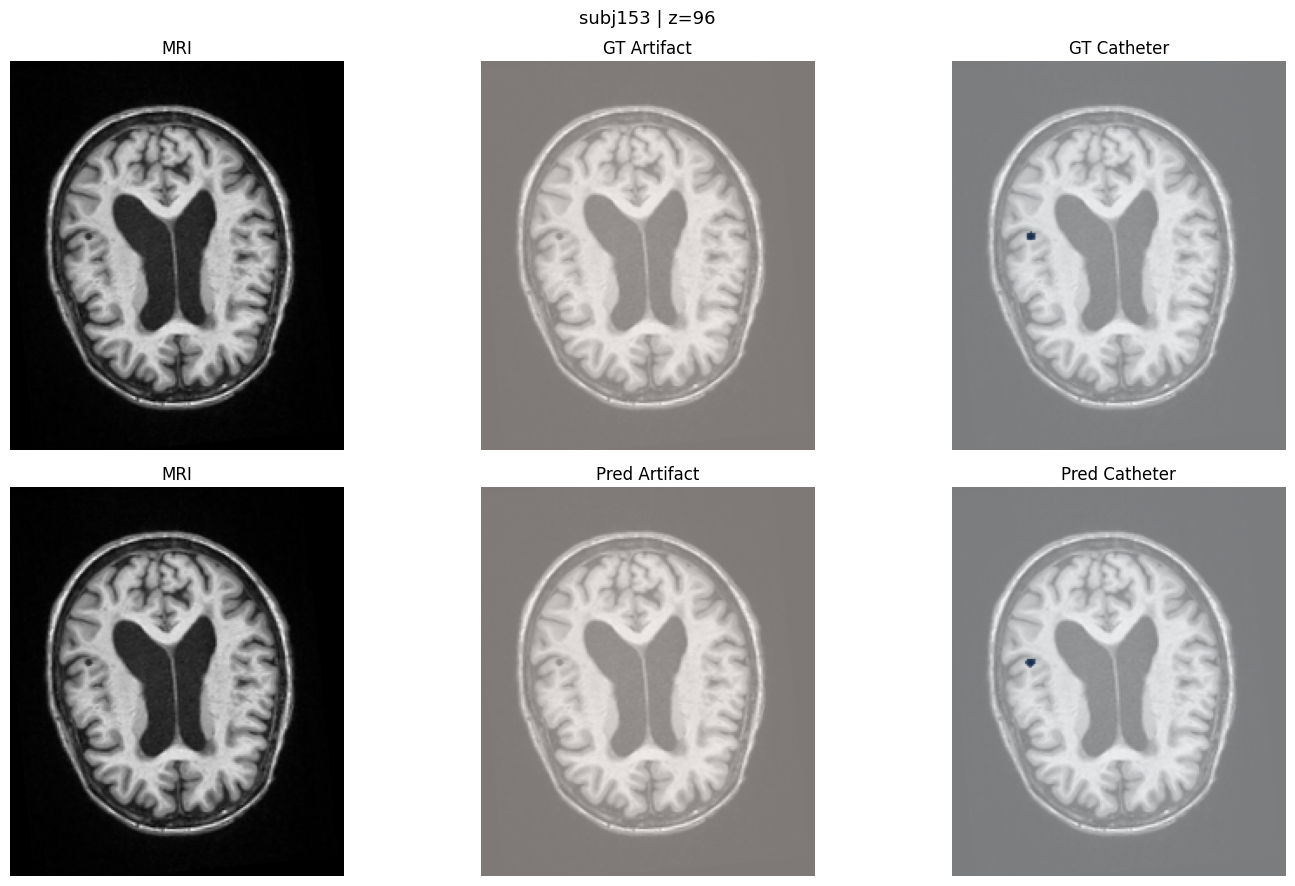

In [ ]:
def visualise_subject(rec, model_a, model_b, axial_z=None):
    """6-panel comparison: GT vs predicted masks overlaid on MRI."""
    vol, sp, _ = load_nifti(rec["image"])
    vol_pre = preprocess_volume(rec["image"])

    pred_art = post_process_artifact(
        sliding_window_inference(model_a, vol_pre, patch_size=CFG["patch_size"], stride=48))
    pred_cat = post_process_catheter(
        sliding_window_inference(model_b, vol_pre, patch_size=CFG["patch_size"], stride=48,
                                extra_ch=pred_art.astype(np.float32)),
        pred_art)

    gt_art, _, _ = load_nifti(rec["artifact"])
    gt_cat, _, _ = load_nifti(rec["catheter"])

    z = axial_z if axial_z else vol.shape[2] // 2
    mri_sl = vol[:, :, z].T

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    titles = [["MRI", "GT Artifact", "GT Catheter"],
              ["MRI", "Pred Artifact", "Pred Catheter"]]
    for r in range(2):
        for c in range(3):
            axes[r, c].set_title(titles[r][c])
            axes[r, c].axis("off")

    axes[0, 0].imshow(mri_sl, cmap="gray", origin="lower")
    axes[0, 1].imshow(mri_sl, cmap="gray", origin="lower")
    axes[0, 1].imshow(gt_art[:, :, z].T, cmap="Reds", origin="lower", alpha=0.5)
    axes[0, 2].imshow(mri_sl, cmap="gray", origin="lower")
    axes[0, 2].imshow(gt_cat[:, :, z].T, cmap="Blues", origin="lower", alpha=0.5)
    axes[1, 0].imshow(mri_sl, cmap="gray", origin="lower")
    axes[1, 1].imshow(mri_sl, cmap="gray", origin="lower")
    axes[1, 1].imshow(pred_art[:, :, z].T, cmap="Reds", origin="lower", alpha=0.5)
    axes[1, 2].imshow(mri_sl, cmap="gray", origin="lower")
    axes[1, 2].imshow(pred_cat[:, :, z].T, cmap="Blues", origin="lower", alpha=0.5)

    plt.suptitle(f"{rec['id']} | z={z}", fontsize=13)
    plt.tight_layout()
    plt.show()


if (OUT_DIR / "model_a_best.pt").exists():
    visualise_subject(val_r[0], model_a, model_b)

In [ ]:
def run_test_inference(test_root, model_a, model_b, out_dir=OUT_DIR):
    out_dir.mkdir(exist_ok=True)
    test_records = get_subject_paths(test_root, labeled=False)
    length_rows = []

    model_a.eval()
    model_b.eval()

    for rec in tqdm(test_records, desc="Test inference"):
        vol, sp, ref_img = load_nifti(rec["image"])
        vol_pre = preprocess_volume(rec["image"])
        sid = rec["id"]

        pred_art = post_process_artifact(
            sliding_window_inference(model_a, vol_pre,
                                    patch_size=CFG["patch_size"], stride=32))
        save_nifti(pred_art, ref_img, out_dir / f"{sid}_taskA.nii.gz")

        pred_cat = post_process_catheter(
            sliding_window_inference(model_b, vol_pre,
                                    patch_size=CFG["patch_size"], stride=32,
                                    extra_ch=pred_art.astype(np.float32)),
            pred_art)
        save_nifti(pred_cat, ref_img, out_dir / f"{sid}_taskB.nii.gz")

        length = estimate_catheter_length(pred_cat, pred_art, sp)
        length_rows.append({"subject": sid, "length": round(length, 2)})

    df_c = pd.DataFrame(length_rows)
    df_c.to_csv(out_dir / "taskC.csv", index=False)
    print(f"Saved {len(test_records)} predictions to {out_dir}/")
    return df_c


ckpt_a = OUT_DIR / "model_a_best.pt"
ckpt_b = OUT_DIR / "model_b_best.pt"
if ckpt_a.exists() and TEST_ROOT.exists():
    model_a.load_state_dict(torch.load(str(ckpt_a), map_location=DEVICE))
    model_b.load_state_dict(torch.load(str(ckpt_b), map_location=DEVICE))
    df_lengths = run_test_inference(TEST_ROOT, model_a, model_b)
    print(df_lengths.head())
else:
    print("Test data or checkpoints not found — train first, then add test data.")

Test data or checkpoints not found — train first, then add test data.


In [ ]:
# Run the grading script on your output vs training GT (optional sanity check)
eval_script = DRIVE_BASE / "data" / "evaluate.py"
if eval_script.exists() and OUT_DIR.exists():
    !python "{eval_script}" \
        --gt-dir "{DATA_ROOT}" \
        --pred-dir "{OUT_DIR}" \
        --output-csv "{OUT_DIR / 'eval_results.csv'}"

In [17]:
def evaluate_length_on_gt(data_root: Path):
    """
    Test the spline-fitting pipeline in isolation using GT masks.
    No U-Net needed — useful for tuning Task C independently.
    """
    records = get_subject_paths(data_root)
    errors = []

    for rec in tqdm(records, desc="GT length eval"):
        cat, sp, _ = load_nifti(rec["catheter"])
        art, _, _ = load_nifti(rec["artifact"])

        pred_len = estimate_catheter_length(
            cat.astype(np.uint8), art.astype(np.uint8), sp)

        if "json" in rec and rec["json"].exists():
            with open(rec["json"]) as f:
                gt_len = json.load(f)["catheter_length_mm"]
            errors.append(pred_len - gt_len)

    errors = np.array(errors)
    print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.2f} mm")
    print(f"Mean Error (bias):   {np.mean(errors):.2f} mm")
    print(f"Std Error:           {np.std(errors):.2f} mm")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(errors, bins=np.arange(min(errors), max(errors) + 0.5, 0.5),
            color="steelblue", edgecolor="white")
    ax.axvline(np.mean(errors), color="red", linestyle="--",
               label=f"Mean: {np.mean(errors):.2f}")
    ax.set_xlabel("Error (mm)")
    ax.set_ylabel("Count")
    ax.set_title("Length Estimation Error on GT Masks")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return errors


# Uncomment to run (takes ~10-20 min on 200 subjects):
gt_errors = evaluate_length_on_gt(DATA_ROOT)

GT length eval:   7%|▋         | 14/200 [00:17<03:50,  1.24s/it]


KeyboardInterrupt: 

Best slice: z=127


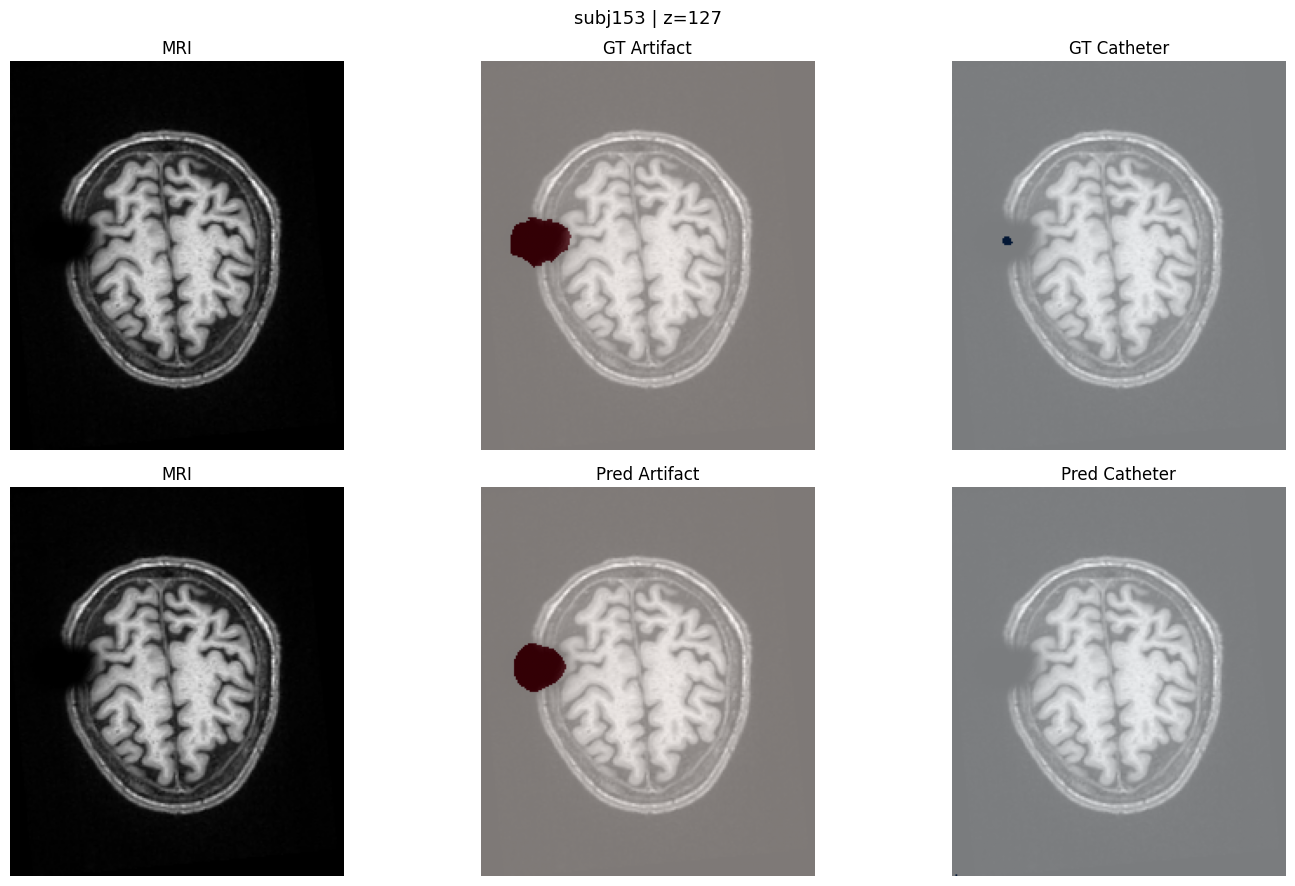

In [ ]:
rec = val_r[0]
gt_art, _, _ = load_nifti(rec["artifact"])
z_best = int(np.argmax(gt_art.sum(axis=(0,1))))
print(f"Best slice: z={z_best}")
visualise_subject(rec, model_a, model_b, axial_z=z_best)